In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "/data/anantaraha/amp/dataset/laion_art/output/xgen_mm/exp3/exp3_image_scores.csv"

df = pd.read_csv(CSV_PATH)

metrics = ["A_MD", "A_DD", "S_gap"]
condition_order = ["source", "adversarial", "target"]

print(f"Rows: {len(df)}")
print(df["condition"].value_counts())

Rows: 150
source         50
adversarial    50
target         50
Name: condition, dtype: int64


In [2]:
summary = (
    df.groupby("condition")[metrics]
      .agg(["mean", "median", "std"])
      .reindex(condition_order)
)

# Make it compact
summary.columns = [f"{metric}_{stat}" for metric, stat in summary.columns]
summary = summary.round(4)

display(summary)

,A_MD_mean,A_MD_median,A_MD_std,A_DD_mean,A_DD_median,A_DD_std,S_gap_mean,S_gap_median,S_gap_std
condition,,,,,,,,,
source,0.8832,0.8861,0.0147,0.9533,0.9572,0.0139,0.0701,0.0708,0.0077
adversarial,0.8373,0.8462,0.0339,0.9352,0.9406,0.0232,0.0979,0.0970,0.0231
target,0.8797,0.8805,0.0154,0.9540,0.9559,0.0106,0.0743,0.0721,0.0124


In [3]:
mean_table = (
    df.groupby("condition")[metrics]
      .mean()
      .reindex(condition_order)
      .round(4)
)

display(mean_table)

,A_MD,A_DD,S_gap
condition,,,
source,0.8832,0.9533,0.0701
adversarial,0.8373,0.9352,0.0979
target,0.8797,0.9540,0.0743


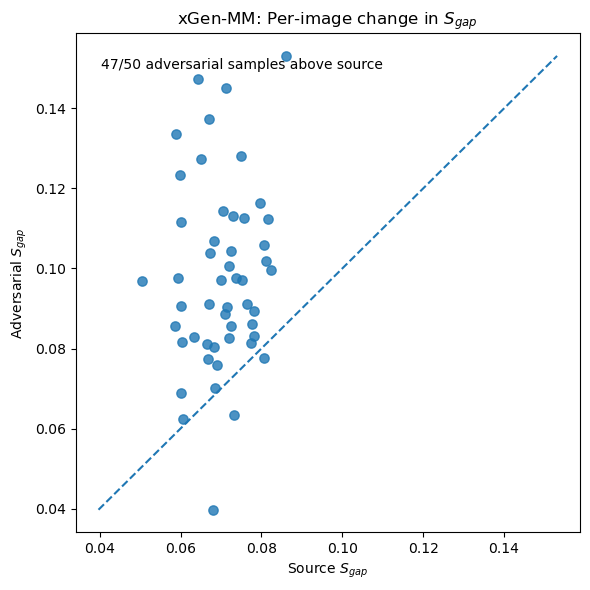

In [4]:
paired = (
    df.pivot(index="sample_id", columns="condition", values="S_gap")
      .dropna(subset=["source", "adversarial"])
)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(paired["source"], paired["adversarial"], s=45, alpha=0.8)

low = min(paired["source"].min(), paired["adversarial"].min())
high = max(paired["source"].max(), paired["adversarial"].max())

ax.plot([low, high], [low, high], "--", linewidth=1.5)

ax.set_xlabel(r"Source $S_{gap}$")
ax.set_ylabel(r"Adversarial $S_{gap}$")
ax.set_title(r"xGen-MM: Per-image change in $S_{gap}$")

n_above = (paired["adversarial"] > paired["source"]).sum()
ax.text(
    0.05, 0.95,
    f"{n_above}/{len(paired)} adversarial samples above source",
    transform=ax.transAxes,
    va="top"
)

plt.tight_layout()
plt.show()

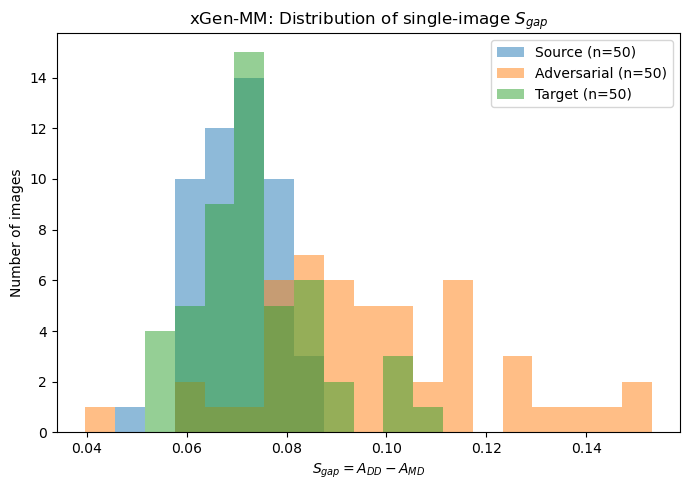

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

all_scores = df["S_gap"].dropna()
bins = np.linspace(all_scores.min(), all_scores.max(), 20)

for condition in condition_order:
    values = df.loc[df["condition"] == condition, "S_gap"].dropna()
    ax.hist(
        values,
        bins=bins,
        alpha=0.5,
        label=f"{condition.capitalize()} (n={len(values)})"
    )

ax.set_xlabel(r"$S_{gap} = A_{DD} - A_{MD}$")
ax.set_ylabel("Number of images")
ax.set_title(r"xGen-MM: Distribution of single-image $S_{gap}$")
ax.legend()

plt.tight_layout()
plt.show()

### RBF patch-token CKA

Run Exp3 with `--cka both` to populate both score files. RBF CKA uses the same patch tokens and depth groups, with a separate median pairwise-distance bandwidth for every image and layer. The tables and plots below repeat the linear analysis for RBF scores.


In [6]:
from pathlib import Path

RBF_CSV_PATH = Path(CSV_PATH).with_name("exp3_rbf_image_scores.csv")
if not RBF_CSV_PATH.is_file():
    raise FileNotFoundError(f"{RBF_CSV_PATH} is missing; run exp3.py with --cka both")

rbf_df = pd.read_csv(RBF_CSV_PATH)
print(f"RBF rows: {len(rbf_df)}")
print(rbf_df["condition"].value_counts())


RBF rows: 150
source         50
adversarial    50
target         50
Name: condition, dtype: int64


In [7]:
rbf_summary = (
    rbf_df.groupby("condition")[metrics]
      .agg(["mean", "median", "std"])
      .reindex(condition_order)
)

# Make it compact
rbf_summary.columns = [f"{metric}_{stat}" for metric, stat in rbf_summary.columns]
rbf_summary = rbf_summary.round(4)

display(rbf_summary)

,A_MD_mean,A_MD_median,A_MD_std,A_DD_mean,A_DD_median,A_DD_std,S_gap_mean,S_gap_median,S_gap_std
condition,,,,,,,,,
source,0.9028,0.9048,0.0128,0.9629,0.9668,0.0110,0.0601,0.0607,0.0068
adversarial,0.8577,0.8657,0.0322,0.9461,0.9506,0.0196,0.0884,0.0853,0.0220
target,0.9003,0.9015,0.0126,0.9631,0.9651,0.0087,0.0628,0.0608,0.0100


In [8]:
rbf_mean_table = (
    rbf_df.groupby("condition")[metrics]
      .mean()
      .reindex(condition_order)
      .round(4)
)

display(rbf_mean_table)

,A_MD,A_DD,S_gap
condition,,,
source,0.9028,0.9629,0.0601
adversarial,0.8577,0.9461,0.0884
target,0.9003,0.9631,0.0628


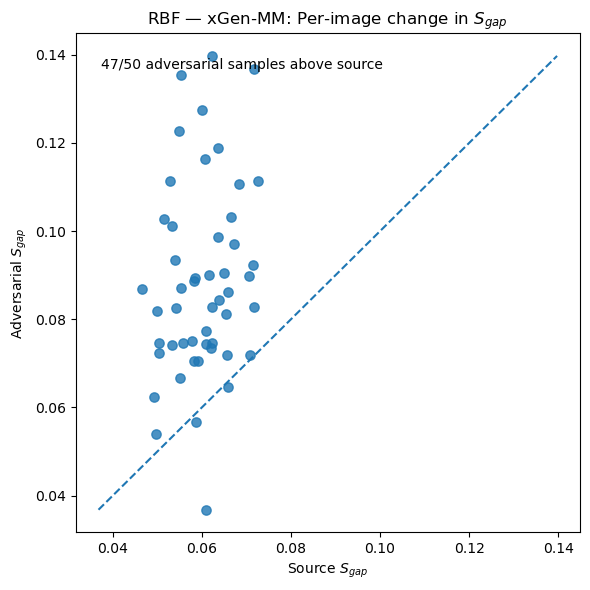

In [9]:
rbf_paired = (
    rbf_df.pivot(index="sample_id", columns="condition", values="S_gap")
      .dropna(subset=["source", "adversarial"])
)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(rbf_paired["source"], rbf_paired["adversarial"], s=45, alpha=0.8)

low = min(rbf_paired["source"].min(), rbf_paired["adversarial"].min())
high = max(rbf_paired["source"].max(), rbf_paired["adversarial"].max())

ax.plot([low, high], [low, high], "--", linewidth=1.5)

ax.set_xlabel(r"Source $S_{gap}$")
ax.set_ylabel(r"Adversarial $S_{gap}$")
ax.set_title(r"RBF — xGen-MM: Per-image change in $S_{gap}$")

rbf_n_above = (rbf_paired["adversarial"] > rbf_paired["source"]).sum()
ax.text(
    0.05, 0.95,
    f"{rbf_n_above}/{len(rbf_paired)} adversarial samples above source",
    transform=ax.transAxes,
    va="top"
)

plt.tight_layout()
plt.show()

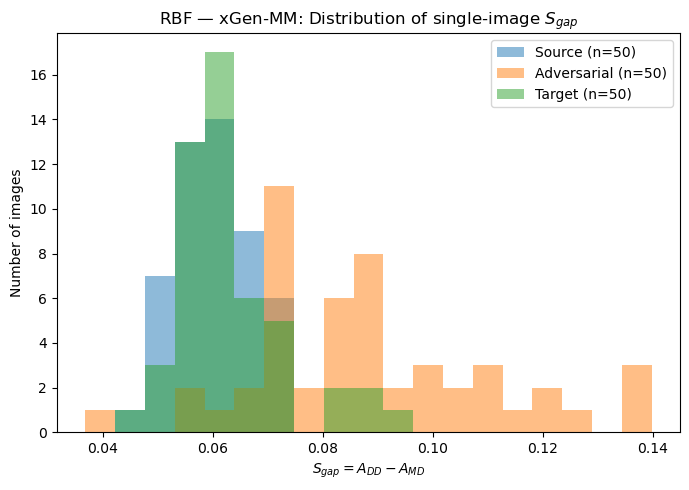

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

rbf_all_scores = rbf_df["S_gap"].dropna()
rbf_bins = np.linspace(rbf_all_scores.min(), rbf_all_scores.max(), 20)

for condition in condition_order:
    values = rbf_df.loc[rbf_df["condition"] == condition, "S_gap"].dropna()
    ax.hist(
        values,
        bins=rbf_bins,
        alpha=0.5,
        label=f"{condition.capitalize()} (n={len(values)})"
    )

ax.set_xlabel(r"$S_{gap} = A_{DD} - A_{MD}$")
ax.set_ylabel("Number of images")
ax.set_title(r"RBF — xGen-MM: Distribution of single-image $S_{gap}$")
ax.legend()

plt.tight_layout()
plt.show()

### Linear versus RBF

Compare only complete triplets shared by both kernels, checking sample/image provenance first. Report condition summaries, paired changes, distributions, and the existing exploratory count/fraction of adversarial scores above source scores. These are descriptive comparisons, not detection thresholds or classifier performance; repeated clean images are not independent observations.


In [11]:
COMPARISON_MODEL = "xGen-MM"

# Compare complete, matching triplets; preserve identifiers when reading both CSVs.
id_columns = ["sample_id", "pair_id", "source_image_id", "target_image_id"]
comparison_inputs = {
    "linear": pd.read_csv(CSV_PATH, dtype={column: str for column in id_columns}),
    "rbf": pd.read_csv(RBF_CSV_PATH, dtype={column: str for column in id_columns}),
}
comparison_keys = ["sample_id", "condition"]
complete_ids = {}
for kernel, frame in comparison_inputs.items():
    if frame.duplicated(comparison_keys).any():
        raise ValueError(f"{kernel}: duplicate sample/condition rows")
    if not np.isfinite(frame[metrics].to_numpy(dtype=float)).all():
        raise ValueError(f"{kernel}: nonfinite scores")
    complete = frame.groupby("sample_id")["condition"].agg(
        lambda values: set(values) == set(condition_order)
    )
    complete_ids[kernel] = set(complete.index[complete])

matched_rows = comparison_inputs["linear"].merge(
    comparison_inputs["rbf"], on=comparison_keys, suffixes=("_linear", "_rbf"),
    how="inner", validate="one_to_one",
)
for column in ["pair_id", "source_image_id", "target_image_id",
               "source_concept", "target_concept", "image_id", "image_path"]:
    present = [column in frame for frame in comparison_inputs.values()]
    if any(present):
        if not all(present):
            raise ValueError(f"Missing comparison provenance: {column}")
        if not matched_rows[f"{column}_linear"].fillna("").equals(
            matched_rows[f"{column}_rbf"].fillna("")):
            raise ValueError(f"Linear/RBF provenance mismatch: {column}")

common_ids = complete_ids["linear"] & complete_ids["rbf"]
if not common_ids:
    raise ValueError("No complete matching linear/RBF triplets to compare")
comparison_scores = pd.concat(
    [frame.loc[frame["sample_id"].isin(common_ids)].assign(cka=kernel)
     for kernel, frame in comparison_inputs.items()],
    ignore_index=True,
)
print(f"Comparison: {len(common_ids)} matched complete triplets")
for kernel, frame in comparison_inputs.items():
    print(f"{kernel}: {frame['sample_id'].nunique()} recorded samples; "
          f"{frame['sample_id'].nunique() - len(common_ids)} excluded from the comparison")


Comparison: 50 matched complete triplets
linear: 50 recorded samples; 0 excluded from the comparison
rbf: 50 recorded samples; 0 excluded from the comparison


In [12]:
comparison_summary = (
    comparison_scores.groupby(["cka", "condition"])[metrics]
      .agg(["mean", "median", "std"])
      .reindex(pd.MultiIndex.from_product(
          [["linear", "rbf"], condition_order], names=["cka", "condition"]
      ))
)
comparison_summary.columns = [
    f"{metric}_{stat}" for metric, stat in comparison_summary.columns
]
display(comparison_summary.round(4))


A_MD_mean  A_MD_median  A_MD_std  A_DD_mean  A_DD_median  \
cka    condition                                                               
linear source          0.8832       0.8861    0.0147     0.9533       0.9572   
       adversarial     0.8373       0.8462    0.0339     0.9352       0.9406   
       target          0.8797       0.8805    0.0154     0.9540       0.9559   
rbf    source          0.9028       0.9048    0.0128     0.9629       0.9668   
       adversarial     0.8577       0.8657    0.0322     0.9461       0.9506   
       target          0.9003       0.9015    0.0126     0.9631       0.9651   

                    A_DD_std  S_gap_mean  S_gap_median  S_gap_std  
cka    condition                                                   
linear source         0.0139      0.0701        0.0708     0.0077  
       adversarial    0.0232      0.0979        0.0970     0.0231  
       target         0.0106      0.0743        0.0721     0.0124  
rbf    source         0.0110      0.0601        0.0607     0.0068  
       adversarial    0.0196      0.0884        0.0853     0.0220  
       target         0.0087      0.0628        0.0608     0.0100

,n_pairs,adv_above_source,fraction_adv_above_source,mean_adv_minus_source,median_adv_minus_source,std_adv_minus_source
cka,,,,,,
linear,50,47,0.94,0.0277,0.024,0.0235
rbf,50,47,0.94,0.0283,0.023,0.0217


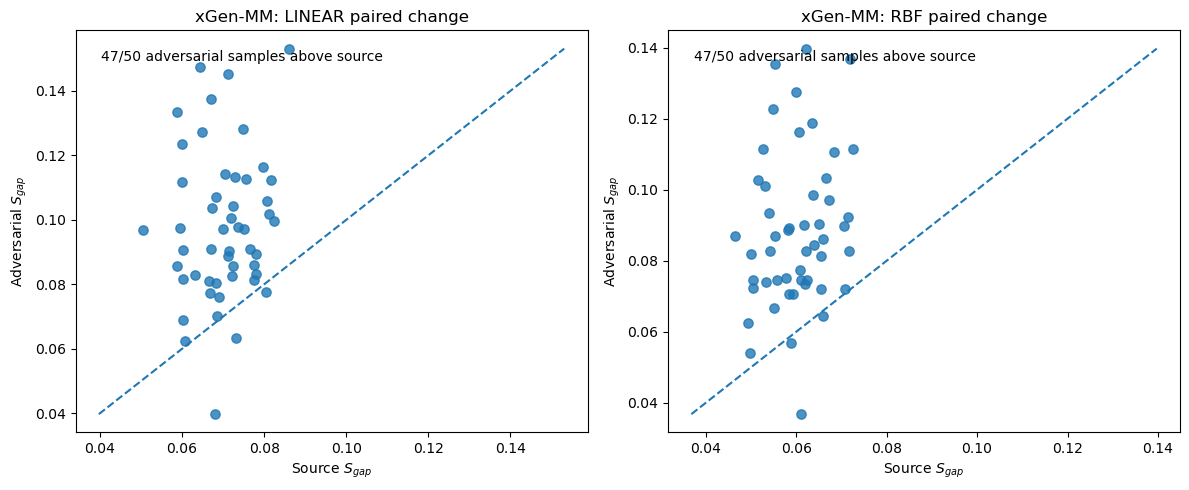

In [13]:
comparison_paired = {}
paired_comparison_rows = []
for kernel in ["linear", "rbf"]:
    values = comparison_scores.loc[comparison_scores["cka"] == kernel]
    pairs = values.pivot(index="sample_id", columns="condition", values="S_gap")
    comparison_paired[kernel] = pairs
    changes = pairs["adversarial"] - pairs["source"]
    above = int((changes > 0).sum())
    paired_comparison_rows.append({
        "cka": kernel,
        "n_pairs": len(pairs),
        "adv_above_source": above,
        "fraction_adv_above_source": above / len(pairs),
        "mean_adv_minus_source": changes.mean(),
        "median_adv_minus_source": changes.median(),
        "std_adv_minus_source": changes.std(),
    })
paired_comparison = pd.DataFrame(paired_comparison_rows).set_index("cka")
display(paired_comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, kernel in zip(axes, ["linear", "rbf"]):
    pairs = comparison_paired[kernel]
    ax.scatter(pairs["source"], pairs["adversarial"], s=45, alpha=0.8)
    low = min(pairs["source"].min(), pairs["adversarial"].min())
    high = max(pairs["source"].max(), pairs["adversarial"].max())
    ax.plot([low, high], [low, high], "--", linewidth=1.5)
    ax.set_xlabel(r"Source $S_{gap}$")
    ax.set_ylabel(r"Adversarial $S_{gap}$")
    ax.set_title(f"{COMPARISON_MODEL}: {kernel.upper()} paired change")
    above = int((pairs["adversarial"] > pairs["source"]).sum())
    ax.text(0.05, 0.95, f"{above}/{len(pairs)} adversarial samples above source",
            transform=ax.transAxes, va="top")
plt.tight_layout()
plt.show()


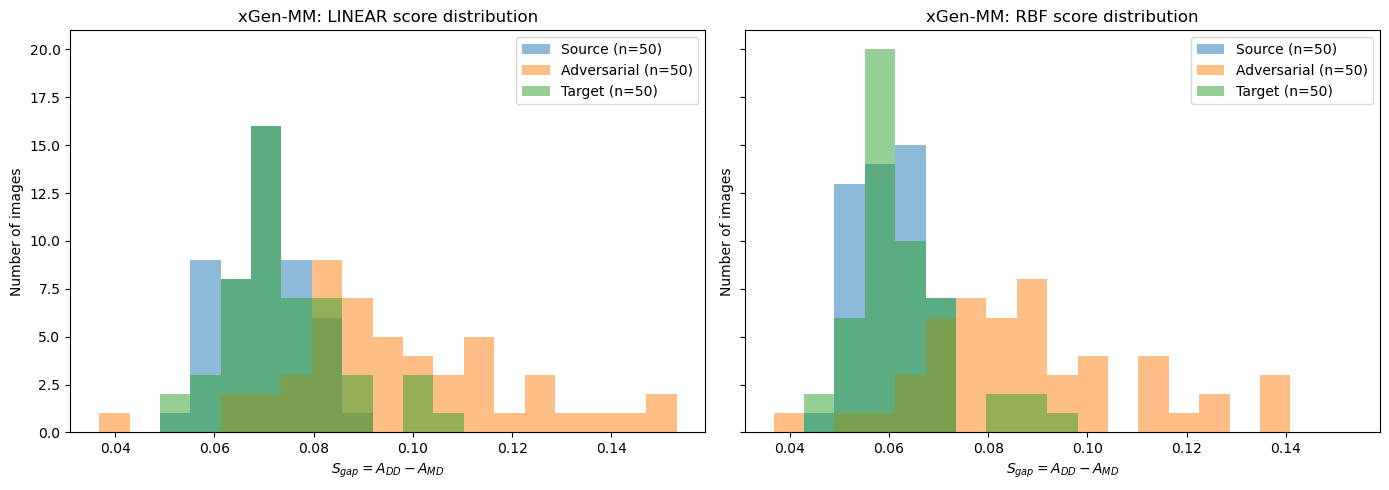

In [14]:
# A shared bin range makes score distributions directly comparable.
comparison_values = comparison_scores["S_gap"].dropna()
low, high = comparison_values.min(), comparison_values.max()
if low == high:
    padding = max(abs(low), 1.0) * 1e-6
    low, high = low - padding, high + padding
comparison_bins = np.linspace(low, high, 20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
for ax, kernel in zip(axes, ["linear", "rbf"]):
    values = comparison_scores.loc[comparison_scores["cka"] == kernel]
    for condition in condition_order:
        scores = values.loc[values["condition"] == condition, "S_gap"].dropna()
        ax.hist(scores, bins=comparison_bins, alpha=0.5,
                label=f"{condition.capitalize()} (n={len(scores)})")
    ax.set_xlabel(r"$S_{gap} = A_{DD} - A_{MD}$")
    ax.set_ylabel("Number of images")
    ax.set_title(f"{COMPARISON_MODEL}: {kernel.upper()} score distribution")
    ax.legend()
plt.tight_layout()
plt.show()


For either kernel, a larger `S_gap` means stronger deep-to-deep alignment relative to middle-to-deep alignment. Compare the direction and distribution of paired changes across kernels; an increase is evidence about this sample set, not proof of an AMP detector. Each kernel uses its own geometry, so their score magnitudes need not agree. RBF triplets with undefined bandwidth are listed in `exp3_rbf_skipped_samples.csv`.
